In [1]:
# Cell 1 — Imports and config
import os, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

BASE       = '/scratch.global/ocon0444/peat_modeling'
MDL_DIR    = os.path.join(BASE, '03_models/exp426')
RES_DIR    = os.path.join(BASE, '05_results/exp426')
CSV_PATH   = os.path.join(BASE, '00_data/processed/organic_composition_features_extracted.csv')
EXP410_DIR = os.path.join(BASE, '03_models/exp410')
CATALOG    = os.path.join(BASE, 'MODEL_CATALOG.csv')

TARGETS     = ['Fibric_pct', 'Hemic_pct', 'Sapric_pct']
COLORS      = {'Fibric': '#3498db', 'Hemic': '#e67e22', 'Sapric': '#8e44ad'}
PROB_THRESH = 0.33
N_FOLDS     = 5

with open(os.path.join(MDL_DIR, 'feature_list.json')) as f:
    meta = json.load(f)
feature_cols = meta['features']

print(f'exp426 — {meta["method"]}')
print(f'Step 1: {meta["step1_target"]}')
print(f'Step 2: {meta["step2_target"]}')
print(f'n_samples: {meta["n_samples"]}  n_features: {meta["n_features"]}')
print()
print('Results from training:')
for k, v in meta['results'].items():
    print(f'  {k}: {v}')

exp426 — iterative_residual
Step 1: Fibric_pct (normalized to sum=100)
Step 2: Hemic / (Hemic + Sapric) fraction
n_samples: 10679  n_features: 15

Results from training:
  fibric_r2: 0.3453
  hemic_r2: 0.3157
  sapric_r2: 0.5386
  mean_r2: 0.3999
  fibric_mae: 18.86
  hemic_mae: 26.28
  sapric_mae: 18.05


In [2]:
# Cell 2 — Load models
models_fibric     = [pickle.load(open(os.path.join(MDL_DIR, f'model_fibric_fold_{i}.pkl'),'rb')) for i in range(N_FOLDS)]
models_hemic_frac = [pickle.load(open(os.path.join(MDL_DIR, f'model_hemic_frac_fold_{i}.pkl'),'rb')) for i in range(N_FOLDS)]
print(f'Loaded {N_FOLDS} fold models for each step.')

Loaded 5 fold models for each step.


In [3]:
# Cell 3 — Load and prep data (matches training script exactly)
import re
df_all = pd.read_csv(CSV_PATH, low_memory=False)
df_all['mn_nwi_binary'] = ((df_all['mn_nwi_cowardin_10m']==1)|(df_all['mn_nwi_cowardin_10m']==2)).astype(int)
df_all['mn_nwi_cowardin_0'] = (df_all['mn_nwi_cowardin_10m']==0).astype(int)

with open(os.path.join(EXP410_DIR,'feature_list.json')) as f:
    exp410_feats = json.load(f)['features']
exp410_models = [pickle.load(open(os.path.join(EXP410_DIR,f'model_fold_{i}.pkl'),'rb')) for i in range(N_FOLDS)]
exp410_cols   = [c for c in exp410_feats if c in df_all.columns]
X_mask = df_all[exp410_cols].apply(pd.to_numeric,errors='coerce').fillna(0)
peat_prob = np.stack([m.predict_proba(X_mask)[:,1] for m in exp410_models]).mean(axis=0)
df_all['exp410_peat_prob'] = peat_prob

df = df_all[df_all['exp410_peat_prob']>=PROB_THRESH].copy().reset_index(drop=True)
df = df.dropna(subset=TARGETS).reset_index(drop=True)
df = df[df['minnesota_dem_10m'].notna()].reset_index(drop=True)

X = df[feature_cols].apply(pd.to_numeric,errors='coerce')
X = X.fillna(X.median())

# Normalize targets to sum=100%
organic_sum = df[TARGETS].sum(axis=1)
zero_mask = organic_sum == 0
df.loc[zero_mask,'Fibric_pct'] = 33.33
df.loc[zero_mask,'Hemic_pct']  = 33.33
df.loc[zero_mask,'Sapric_pct'] = 33.34
organic_sum = df[TARGETS].sum(axis=1)
fibric_norm = (df['Fibric_pct'] / organic_sum * 100).values
hemic_norm  = (df['Hemic_pct']  / organic_sum * 100).values
sapric_norm = (df['Sapric_pct'] / organic_sum * 100).values
hemic_sapric_sum = hemic_norm + sapric_norm
hemic_frac = np.where(hemic_sapric_sum>0, hemic_norm/hemic_sapric_sum, 0.5)

print(f'Training rows: {len(df):,}')

Training rows: 10,679


In [4]:
# Cell 4 — Rebuild OOF predictions
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
oof_fibric = np.zeros(len(df))
oof_hemic  = np.zeros(len(df))
oof_sapric = np.zeros(len(df))

for fold, (tr_idx, va_idx) in enumerate(kf.split(X)):
    pred_fibric    = np.clip(models_fibric[fold].predict(X.iloc[va_idx]), 0, 100)
    pred_hemic_frac= np.clip(models_hemic_frac[fold].predict(X.iloc[va_idx]), 0, 1)
    remainder      = np.clip(100 - pred_fibric, 0, 100)
    oof_fibric[va_idx] = pred_fibric
    oof_hemic[va_idx]  = remainder * pred_hemic_frac
    oof_sapric[va_idx] = remainder * (1 - pred_hemic_frac)

oof_sum = oof_fibric + oof_hemic + oof_sapric
print(f'OOF sum: mean={oof_sum.mean():.4f}  min={oof_sum.min():.4f}  max={oof_sum.max():.4f}')
print('(Should be exactly 100.00 everywhere)')
print()

print(f"{'Target':<10} {'R²':>8} {'MAE':>8} {'RMSE':>8}")
print('-'*38)
for name, obs, pred in [('Fibric', fibric_norm, oof_fibric),
                         ('Hemic',  hemic_norm,  oof_hemic),
                         ('Sapric', sapric_norm, oof_sapric)]:
    r2   = r2_score(obs, pred)
    mae  = mean_absolute_error(obs, pred)
    rmse = np.sqrt(mean_squared_error(obs, pred))
    print(f'{name:<10} {r2:>8.4f} {mae:>8.2f}% {rmse:>8.2f}%')

OOF sum: mean=100.0000  min=100.0000  max=100.0000
(Should be exactly 100.00 everywhere)

Target           R²      MAE     RMSE
--------------------------------------
Fibric       0.3451    18.86%    27.11%
Hemic        0.3158    26.28%    33.64%
Sapric       0.5385    18.05%    26.35%


                                Model  Fibric R²  Hemic R²  Sapric R²  Mean R²        Sum=100?
  exp422 (independent, post-hoc norm)   0.361000  0.352000   0.589000 0.434000   Post-hoc only
exp426 (iterative residual, sum=100%)   0.345329  0.315682   0.538615 0.399875 By construction


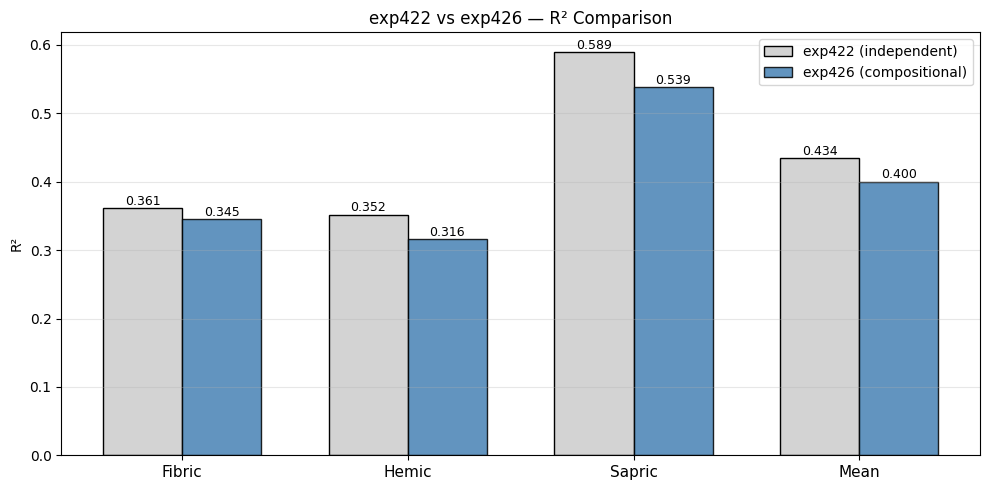

In [5]:
# Cell 5 — Compare exp426 vs exp422
cv = pd.read_csv(os.path.join(MDL_DIR, 'cv_results.csv'))

comparison = {
    'Model':   ['exp422 (independent, post-hoc norm)', 'exp426 (iterative residual, sum=100%)'],
    'Fibric R²': [0.361, cv['r2_fibric'].mean()],
    'Hemic R²':  [0.352, cv['r2_hemic'].mean()],
    'Sapric R²': [0.589, cv['r2_sapric'].mean()],
    'Mean R²':   [0.434, cv['mean_r2'].mean()],
    'Sum=100?':  ['Post-hoc only', 'By construction'],
}
comp_df = pd.DataFrame(comparison)
print(comp_df.to_string(index=False))

# Bar chart comparison
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(4)
w = 0.35
vals_422 = [0.361, 0.352, 0.589, 0.434]
vals_426 = [cv['r2_fibric'].mean(), cv['r2_hemic'].mean(),
            cv['r2_sapric'].mean(), cv['mean_r2'].mean()]
labels   = ['Fibric', 'Hemic', 'Sapric', 'Mean']
b1 = ax.bar(x-w/2, vals_422, w, label='exp422 (independent)', color='lightgray', edgecolor='black')
b2 = ax.bar(x+w/2, vals_426, w, label='exp426 (compositional)', color='steelblue', alpha=0.85, edgecolor='black')
for bar, v in zip(b1, vals_422): ax.text(bar.get_x()+bar.get_width()/2, v+0.005, f'{v:.3f}', ha='center', fontsize=9)
for bar, v in zip(b2, vals_426): ax.text(bar.get_x()+bar.get_width()/2, v+0.005, f'{v:.3f}', ha='center', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('R²'); ax.set_title('exp422 vs exp426 — R² Comparison')
ax.legend(fontsize=10); ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(RES_DIR,'exp422_vs_exp426_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

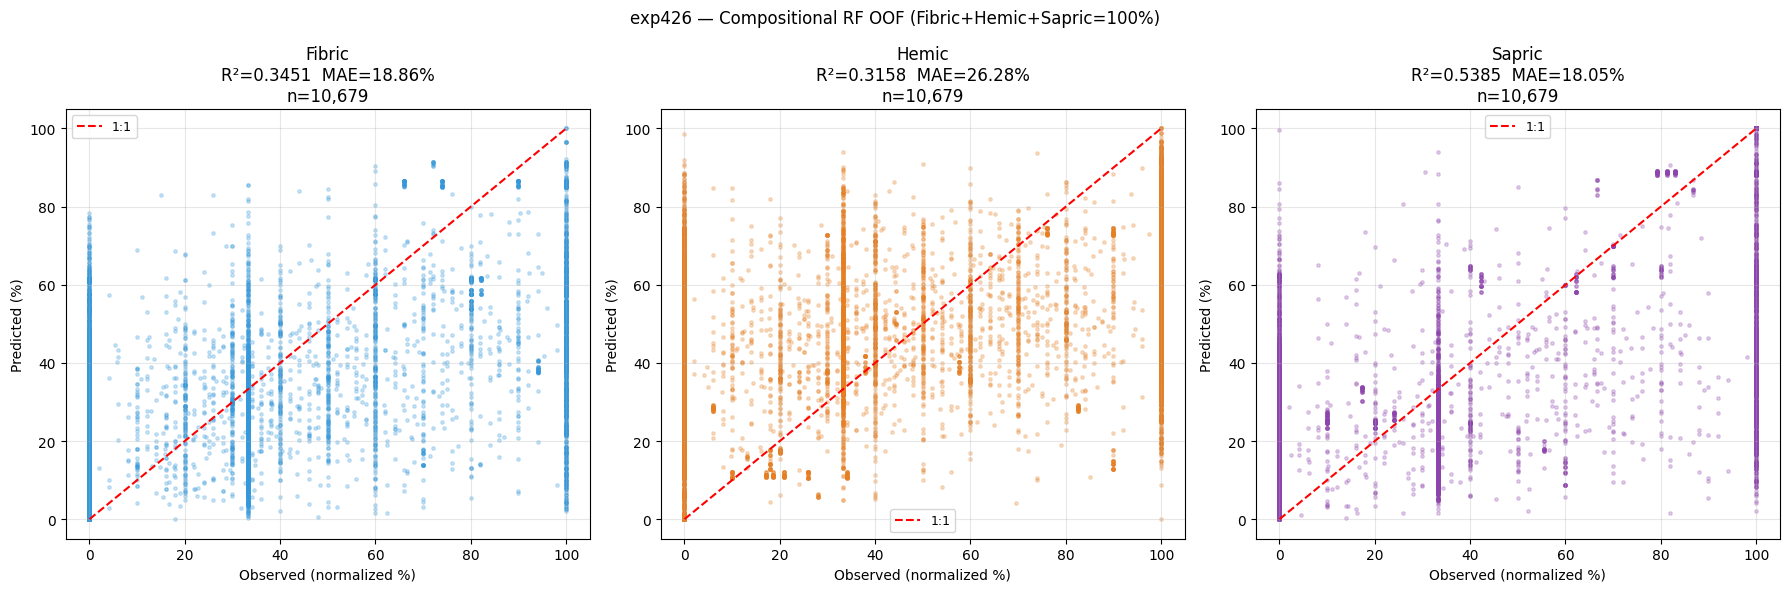

In [6]:
# Cell 6 — Predicted vs observed scatter
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, name, obs, pred in zip(axes,
    ['Fibric','Hemic','Sapric'],
    [fibric_norm, hemic_norm, sapric_norm],
    [oof_fibric, oof_hemic, oof_sapric]):
    r2  = r2_score(obs, pred)
    mae = mean_absolute_error(obs, pred)
    ax.scatter(obs, pred, alpha=0.25, s=6, color=COLORS[name])
    lim = max(obs.max(), pred.max())
    ax.plot([0,lim],[0,lim],'r--',lw=1.5,label='1:1')
    ax.set_xlabel('Observed (normalized %)')
    ax.set_ylabel('Predicted (%)')
    ax.set_title(f'{name}\nR²={r2:.4f}  MAE={mae:.2f}%\nn={len(obs):,}')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.suptitle('exp426 — Compositional RF OOF (Fibric+Hemic+Sapric=100%)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(RES_DIR,'predicted_vs_observed.png'), dpi=150, bbox_inches='tight')
plt.show()

Fibric: obs=24.8%  pred=25.7%
Hemic: obs=46.1%  pred=44.0%
Sapric: obs=29.1%  pred=30.3%


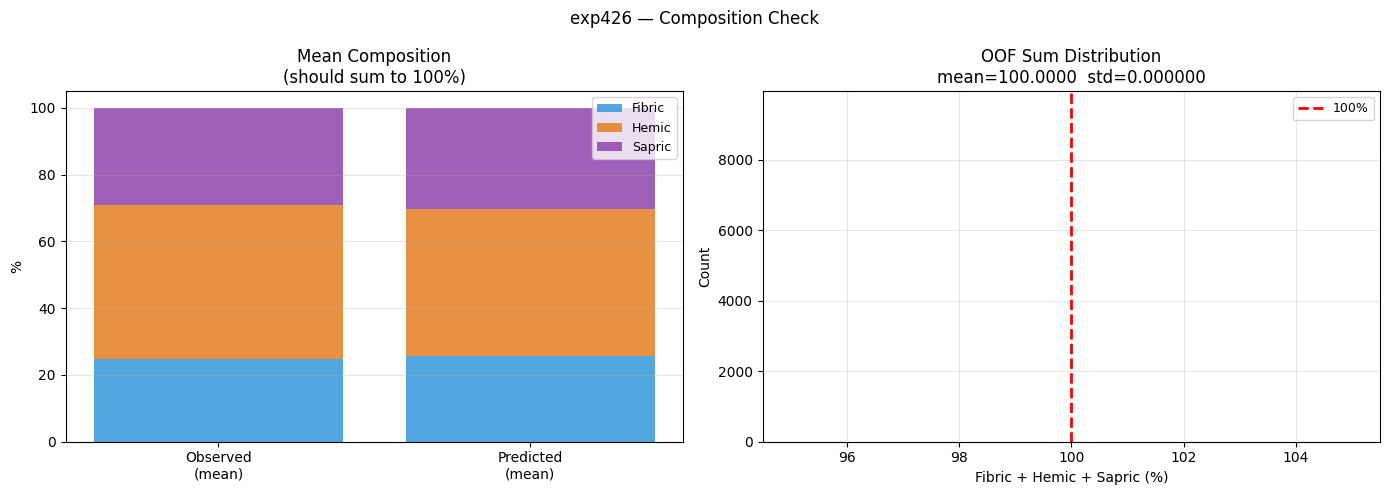


OOF sum: mean=100.000000  std=0.00000000


In [7]:
# Cell 7 — Composition distribution check
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar: observed vs predicted mean composition
cats = ['Fibric','Hemic','Sapric']
obs_means  = [fibric_norm.mean(), hemic_norm.mean(), sapric_norm.mean()]
pred_means = [oof_fibric.mean(), oof_hemic.mean(), oof_sapric.mean()]
clrs = ['#3498db','#e67e22','#8e44ad']
x = np.array([0, 1])
bottom_o = bottom_p = 0
for cat, om, pm, c in zip(cats, obs_means, pred_means, clrs):
    axes[0].bar(0, om, bottom=bottom_o, color=c, alpha=0.85, label=cat)
    axes[0].bar(1, pm, bottom=bottom_p, color=c, alpha=0.85)
    bottom_o += om; bottom_p += pm
axes[0].set_xticks([0,1]); axes[0].set_xticklabels(['Observed\n(mean)','Predicted\n(mean)'])
axes[0].set_ylabel('%'); axes[0].set_title('Mean Composition\n(should sum to 100%)')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3, axis='y')
axes[0].set_ylim(0,105)
for i, (om, pm) in enumerate(zip([fibric_norm.mean(), hemic_norm.mean(), sapric_norm.mean()],
                                   [oof_fibric.mean(), oof_hemic.mean(), oof_sapric.mean()])):
    print(f'{cats[i]}: obs={om:.1f}%  pred={pm:.1f}%')

# OOF sum distribution
axes[1].hist(oof_sum, bins=30, color='steelblue', alpha=0.8)
axes[1].axvline(100, color='red', lw=2, linestyle='--', label='100%')
axes[1].set_xlabel('Fibric + Hemic + Sapric (%)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'OOF Sum Distribution\nmean={oof_sum.mean():.4f}  std={oof_sum.std():.6f}')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)
plt.suptitle('exp426 — Composition Check', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(RES_DIR,'composition_check.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'\nOOF sum: mean={oof_sum.mean():.6f}  std={oof_sum.std():.8f}')